# Arandu examples

Make sure you have an account from [ai-scope.cbpf.br](https://ai-scope.cbpf.br).

Queries use AstroQL. Spatial coordinates and radii are in degrees; source dates are MJD TAI.

In [1]:
from arandu import AranduClient

client = AranduClient()

## A cone search

`cone_search` builds an AstroQL `cone(ra, dec, center_ra, center_dec, radius)` clause.

In [2]:
objects = client.cone_search(
    'arandu.dia_object',
    ra=277.48425,
    dec=13.5576,
    radius_deg=180 / 3600,
    limit=1_000,
)
objects.head()

Check query status at: https://ai-scope.cbpf.br/queries/47e3822f-4a5b-4801-8ea5-79fcc9f7ba31
Results fetched.


,dia_object_id,ra,dec,ra_err,dec_err,n_dia_sources,first_dia_source_mjd_tai,last_dia_source_mjd_tai,validity_start_mjd_tai,f062_psf_flux_mean,...,f184_psf_flux_mean,f184_psf_flux_sigma,f184_psf_flux_ndata,f184_psf_flux_min,f184_psf_flux_max,f213_psf_flux_mean,f213_psf_flux_sigma,f213_psf_flux_ndata,f213_psf_flux_min,f213_psf_flux_max
0,52348240,277.466422,13.526918,None,None,7,61213.362492,61318.207437,61318.207437,327.88312,...,4498.279,0.0,1,4498.279,4498.279,None,None,None,None,None


## Flux and custom filters

Pass a column mapping through `filters`: scalar values mean equality, lists mean `IN`, and `(operator, value)` provides a comparison. `min_flux` and `max_flux` apply to `psf_flux` by default; choose another source flux field with `flux_column`.

In [3]:
bright_sources = client.cone_search(
    'arandu.dia_source',
    ra=277.48425, dec=13.5576, radius_deg=180 / 3600,
    filters={'snr': ('>=', 5), 'band': ['F146', 'F184']},
    min_flux=1_000,
)
bright_sources.head()

Check query status at: https://ai-scope.cbpf.br/queries/50502e37-5835-48eb-8cfe-dc10abd80237
Results fetched.


,dia_source_id,visit,detector,dia_object_id,ss_object_id,parent_dia_source_id,midpoint_mjd_tai,ra,dec,ra_err,...,expid,isdiffpos,qfit,cfit,redchi,npixfit,sharpness,roundness1,roundness2,peak
0,52348240005,52348,16,52348240,None,None,61312.99366,277.466419,13.526917,0.000005,...,52348,True,1.693434,0.021948,2.697439,167,1.190433,-0.006605,0.348479,9.892846


## A polygon search

Pass three or more `(ra, dec)` vertices in boundary order.

In [4]:
polygon_objects = client.polygon_search(
    'arandu.dia_object',
    [(277.40, 13.50), (277.60, 13.50), (277.60, 13.70), (277.40, 13.70)],
    limit=1_000,
)
polygon_objects.head()

Check query status at: https://ai-scope.cbpf.br/queries/7ce08f37-fc3b-41f4-9771-66c73202e5a8
Results fetched.


,dia_object_id,ra,dec,ra_err,dec_err,n_dia_sources,first_dia_source_mjd_tai,last_dia_source_mjd_tai,validity_start_mjd_tai,f062_psf_flux_mean,...,f184_psf_flux_mean,f184_psf_flux_sigma,f184_psf_flux_ndata,f184_psf_flux_min,f184_psf_flux_max,f213_psf_flux_mean,f213_psf_flux_sigma,f213_psf_flux_ndata,f213_psf_flux_min,f213_psf_flux_max
0,96023210,277.458029,13.612504,None,None,7,61208.023197,61297.837914,61297.837914,114.40698,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,78211083,277.576909,13.587346,None,None,19,61184.548933,61300.636172,61300.636172,219.75096,...,274.99695,0.645866,4.0,274.61865,276.11557,NaN,NaN,NaN,NaN,NaN
2,80452811,277.435369,13.598894,None,None,16,61197.498589,61306.965243,61306.965243,NaN,...,310.60504,10.922928,3.0,302.82962,326.05230,2270.1292,657.83660,3.0,1484.60130,3094.5562
3,50939728,277.567903,13.502012,None,None,19,61195.039193,61307.274552,61307.274552,693.26320,...,191.57524,49.006294,3.0,129.20323,248.92850,1003.9353,512.49450,4.0,147.76738,1484.7538
4,49951929,277.428926,13.537970,None,None,17,61192.916688,61310.471698,61310.471698,2321.44850,...,224.78100,0.000000,1.0,224.78100,224.78100,1145.4231,246.38618,2.0,899.03690,1391.8092


## Download a date range and larger results

`sources_by_date` selects `midpoint_mjd_tai`. For large results, use date intervals: each request directly filters the indexed time column, without `OFFSET` or a global sort.

In [5]:
sources = client.sources_by_date(61318, 61319, limit=50_000)
sources

Check query status at: https://ai-scope.cbpf.br/queries/1cd482b3-929d-4724-8664-d82bcf3de03d
Results fetched.


,dia_source_id,visit,detector,dia_object_id,ss_object_id,parent_dia_source_id,midpoint_mjd_tai,ra,dec,ra_err,...,expid,isdiffpos,qfit,cfit,redchi,npixfit,sharpness,roundness1,roundness2,peak
0,9514191202,9514,14,15400978,None,None,61318.000001,175.128237,-23.889375,2.195299e-06,...,9514,True,1.507224,0.061129,0.756699,90,0.743356,-0.633721,-0.636336,28.096846
1,9514191203,9514,4,88046109,None,None,61318.000002,80.113047,-54.661257,3.338369e-06,...,9514,True,2.322675,0.099418,1.141089,71,0.515062,0.532847,0.804048,59.279205
2,9514191204,9514,7,39836616,None,None,61318.000003,103.386672,10.128706,4.194519e-07,...,9514,True,2.382896,0.002379,1.257730,166,0.717886,0.040633,-0.545019,99.541350
3,47577433015,47577,3,47577433,None,None,61318.000004,273.632843,11.548235,3.777916e-06,...,47577,True,1.169669,0.046332,1.836811,137,0.499700,-0.869414,0.163399,26.735655
4,9514191205,9514,15,84337272,None,None,61318.000004,309.902445,-47.293299,4.580781e-06,...,9514,True,2.244271,0.029167,2.052529,156,0.577772,-0.204343,0.911991,5.969330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,9514233532,9514,2,63758077,None,None,61318.048994,98.401178,0.963112,4.744432e-06,...,9514,True,1.022472,0.017248,2.843480,315,0.384713,-0.650295,-0.564015,38.282867
49996,9514233533,9514,15,78673694,None,None,61318.048995,113.804907,-44.234162,2.124693e-06,...,9514,True,0.587280,0.019109,2.411125,360,0.502325,0.933234,-0.946282,92.547490
49997,9514233534,9514,14,45824466,None,None,61318.048996,265.990722,-45.014952,3.040052e-06,...,9514,True,1.734553,0.045689,2.095746,212,0.731085,-0.977624,0.582618,37.328896
49998,9514233535,9514,5,13624481,None,None,61318.048997,153.811067,-12.376320,4.046580e-06,...,9514,True,1.960855,0.006325,1.770740,221,0.264396,0.947987,0.381004,15.430095


In [6]:
for batch in client.sources_by_date_batches(
    61318, 61320,
    interval_days=1,
    objects_per_batch=2000,
):
    # Save or process each date interval here.
    print(f'Received {len(batch):,} rows')
    break

Check query status at: https://ai-scope.cbpf.br/queries/49ba600d-39aa-4a85-998d-5be1172e05c7
Results fetched.
Check query status at: https://ai-scope.cbpf.br/queries/75411b98-f3b1-4c4c-a627-56d4daf243e9
Results fetched.
Received 2,111 rows


## Complete DIA-object light curve

The date selection above chooses an object; this cell then fetches its complete `dia_source` history. Set `LIGHTCURVE_OBJECT_ID` explicitly to plot another object. Measurements are separated by Roman band, with PSF-flux uncertainties when available.

In [7]:
int(sources['dia_object_id'].dropna().value_counts().index[0])

41784210

Fetching complete light curve for DIA object 41784210...
Check query status at: https://ai-scope.cbpf.br/queries/e8c164c1-9cd0-440a-81d6-1a8cbb40913a
Results fetched.


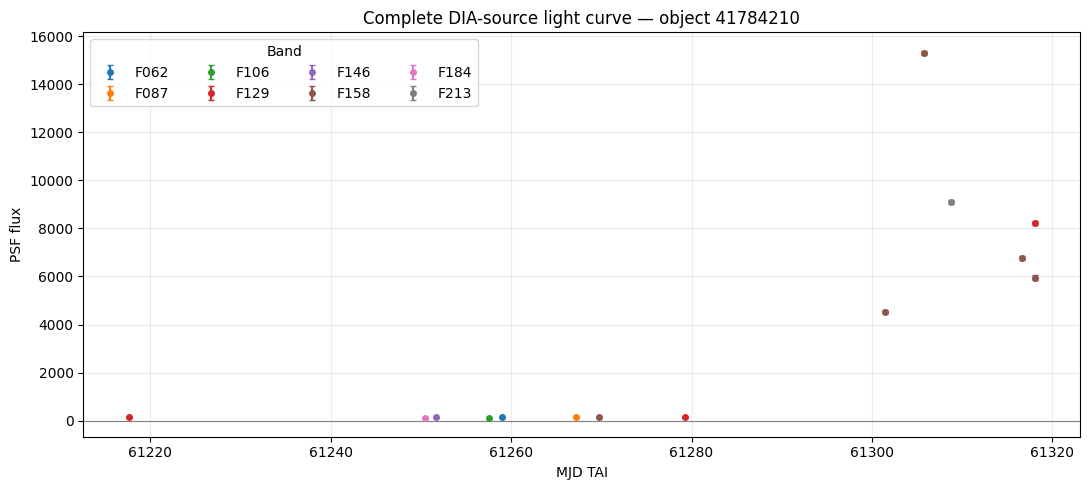

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

required_columns = {'dia_object_id'}
if not required_columns.issubset(sources.columns) or sources['dia_object_id'].dropna().empty:
    print('Choose a date range that returns a DIA object, or set LIGHTCURVE_OBJECT_ID manually.')
else:
    LIGHTCURVE_OBJECT_ID = int(sources['dia_object_id'].dropna().value_counts().index[0])
    # Use limit=None to retrieve the complete history rather than a sample.
    print(f'Fetching complete light curve for DIA object {LIGHTCURVE_OBJECT_ID}...')
    lightcurve = client.sources(LIGHTCURVE_OBJECT_ID, limit=None).copy()
    lightcurve['mjd'] = pd.to_numeric(lightcurve['midpoint_mjd_tai'], errors='coerce')
    lightcurve['flux'] = pd.to_numeric(lightcurve['psf_flux'], errors='coerce')
    lightcurve['flux_err'] = (pd.to_numeric(lightcurve['psf_flux_err'], errors='coerce')
                              if 'psf_flux_err' in lightcurve else float('nan'))
    bands = (lightcurve['band'].fillna('unknown') if 'band' in lightcurve
             else pd.Series('unknown', index=lightcurve.index))
    fig, axis = plt.subplots(figsize=(11, 5))
    for band, measurements in lightcurve.groupby(bands, dropna=False):
        measurements = measurements.dropna(subset=['mjd', 'flux']).sort_values('mjd')
        axis.errorbar(measurements['mjd'], measurements['flux'], yerr=measurements['flux_err'],
                      fmt='o', ms=4, capsize=2, label=str(band))
    axis.axhline(0, color='0.5', lw=0.8)
    axis.set(title=f'Complete DIA-source light curve — object {LIGHTCURVE_OBJECT_ID}',
             xlabel='MJD TAI', ylabel='PSF flux')
    axis.grid(alpha=0.25)
    axis.legend(title='Band', ncols=4)
    plt.tight_layout()
    plt.show()

## Display alert cutouts

Provide an alert from the broker (or an alert ID). The helper uses a URL published in `alert['payload']['cutouts']` when available, otherwise it uses the standard cutout endpoint.

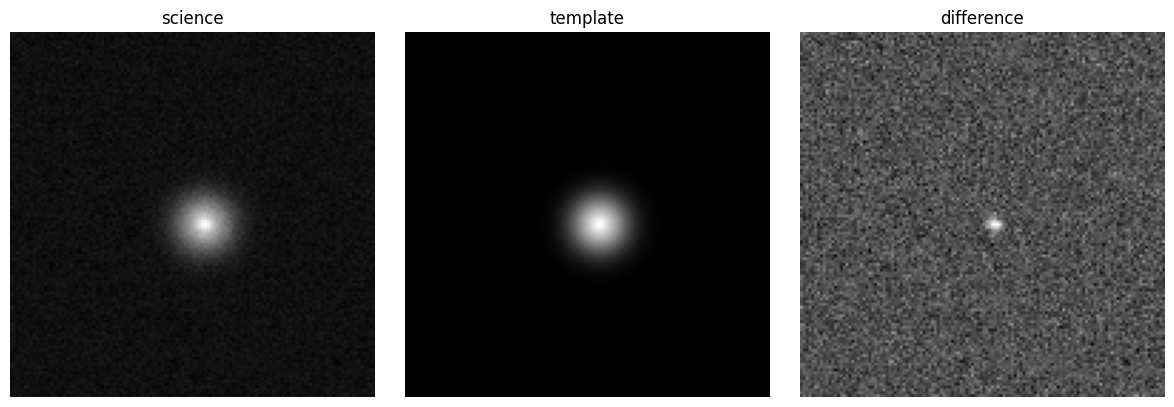

In [13]:
import matplotlib.pyplot as plt
from arandu import CUTOUT_KINDS, download_cutout

# Replace this with an alert returned by the broker.
alert = {'alert_id': 9514233533}

fig, axes = plt.subplots(1, len(CUTOUT_KINDS), figsize=(12, 4))
for axis, kind in zip(axes, CUTOUT_KINDS):
    image = download_cutout(alert, kind)
    axis.imshow(image, origin='lower', cmap='gray')
    axis.set_title(kind)
    axis.set_axis_off()
plt.tight_layout()

## Listen for real-time alerts

The listener is a Server-Sent Events stream. This example starts at the latest alert and follows new events. Remove the `break` in a service or worker that should run continuously.

In [2]:
client.alert_categories()  # inspect the category names available to this account

[{'name': 'all',
  'description': 'All Roman Alerts',
  'created_at': '2026-03-30T13:28:09.407189'},
 {'name': 'rapid-high-confidence',
  'description': 'High-confidence transient candidates from RAPID',
  'created_at': '2026-09-15T19:40:06.525770'}]

In [3]:
for number, alert in enumerate(
    client.listen_alerts(
        categories=['rapid-high-confidence'],
        replay='latest',
    ),
    start=1,
):
    print(alert)
    if number == 5:  # demonstration only; a production worker keeps listening
        break

{'alert_id': '9514831661', 'source': 'RAPID', 'category': 'rapid-high-confidence', 'ra': 54.77242732824949, 'dec': 7.69912422441746, 'mjd': 61318.741272796586, 'magnitude': 22.061026663929443, 'filter_band': 'F146', 'payload': {'snr': 58.77080535888672, 'psfFlux': 5440.208984375, 'psfFluxErr': 92.56651306152344, 'extendedness': 0.4004810154438019, 'sharpness': 1.03799569606781, 'roundness1': 0.8588700890541077, 'roundness2': 0.4211660921573639, 'flags': 0, 'sca': 11, 'field': 4362131, 'hp6': 26655, 'hp9': 1821695, 'cutouts': {'science': 'https://arandu-portal.cbpf.br/api/cutouts/9514831661/science.fits', 'template': 'https://arandu-portal.cbpf.br/api/cutouts/9514831661/template.fits', 'difference': 'https://arandu-portal.cbpf.br/api/cutouts/9514831661/difference.fits'}}}
{'alert_id': '9514831672', 'source': 'RAPID', 'category': 'rapid-high-confidence', 'ra': 264.17440762252374, 'dec': 8.585166947790867, 'mjd': 61318.74128552775, 'magnitude': 22.97281960096065, 'filter_band': 'F213', 'p

## Filter enrichments by classification and date

`enrichments_by_classification` always requires a classification and a half-open UTC window (`[start, end)`). It uses the enrichment time and can be limited to one enricher.

In [6]:
classified = client.enrichments_by_classification(
    'high_confidence_transient',
    '2026-10-03T00:00:00+00:00',
    '2026-10-08T00:00:00+00:00',
    #enricher_name='simple-transient-classifier',
    limit=1_000,
)
classified.head()

Check query status at: https://ai-scope.cbpf.br/queries/a46048b4-cace-484d-8ce8-c1697306a9e2
Results fetched.


,enrichment_id,dia_source_id,enricher_name,version,value,enriched_at,additionals,dia_object_id,midpoint_mjd_tai,band,ra,dec,ingested_at
0,39127022,9515499293,simple-transient-classifier,1.1.0,"{'label': 'high_confidence_transient', 'score'...",2026-10-06 12:20:10.220429,{'features': {'extendedness': 0.02057731524109...,20139979,61319.513995,F158,298.652693,14.375571,2026-10-06 12:20:10.427325
1,39127013,9515499290,simple-transient-classifier,1.1.0,"{'label': 'high_confidence_transient', 'score'...",2026-10-06 12:20:10.200129,{'features': {'extendedness': 0.79673022031784...,54756696,61319.513992,F213,146.345200,19.395286,2026-10-06 12:20:10.427325
2,39126989,9515499282,simple-transient-classifier,1.1.0,"{'label': 'high_confidence_transient', 'score'...",2026-10-06 12:20:09.186541,{'features': {'extendedness': 0.00075114966602...,95005212,61319.513982,F146,55.533046,13.938465,2026-10-06 12:20:09.345397
3,39126971,9515499276,simple-transient-classifier,1.1.0,"{'label': 'high_confidence_transient', 'score'...",2026-10-06 12:20:09.156517,{'features': {'extendedness': 0.06832635402679...,98688452,61319.513975,F106,185.586042,3.833533,2026-10-06 12:20:09.345397
4,39126965,9515499274,simple-transient-classifier,1.1.0,"{'label': 'high_confidence_transient', 'score'...",2026-10-06 12:20:09.147828,{'features': {'extendedness': 0.21243701875209...,32433780,61319.513973,F129,160.475203,3.392336,2026-10-06 12:20:09.345397


## Native SQL

Use `raw_query` when PostgreSQL-specific syntax, such as JSONB operators, is needed. Only interpolate trusted values.

In [ ]:
usable = client.raw_query("""
    SELECT enrichment_id, dia_source_id, enricher_name, value, enriched_at
    FROM arandu.enrichment
    WHERE value->>'label' = 'usable'
    ORDER BY enriched_at DESC
    LIMIT 100
""")
usable.head()